In [31]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df_nycbike = pd.read_csv('202307-citibike-tripdata.csv')
df_nycbike.head()

In [ ]:
df_nycbike['datetime_start'] = pd.to_datetime(df_nycbike['started_at'])
df_nycbike['datetime_end'] = pd.to_datetime(df_nycbike['ended_at'])

df_nycbike.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,datetime_start,datetime_end,ride duration


In [178]:
df_nycbike['ride duration'] = (df_nycbike['datetime_end'] - df_nycbike['datetime_start']).dt.total_seconds()/60
np.mean(df_nycbike['ride duration'])

13.249745556569016

In [184]:
df_nycbike[df_nycbike['ride duration']<0]

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,datetime_start,datetime_end,ride duration


In [179]:
df_nycbike = df_nycbike[(df_nycbike['ride duration']<200) & (df_nycbike['ride duration']>0)]
np.mean(df_nycbike['ride duration'])

13.249745556569016

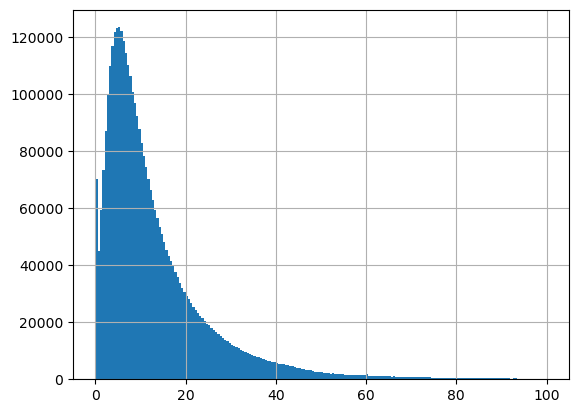

In [181]:
plt.hist(df_nycbike['ride duration'], bins = 200)
plt.grid(True)
plt.show()

In [123]:
print('Expected ride duration:', np.mean(df_nycbike['ride duration']), 'minutes')
print('Variance ride duration:', np.var(df_nycbike['ride duration']))
print('P(X > 20minutes):', (len(df_nycbike[df_nycbike['ride duration'] > 20])/len(df_nycbike['ride duration'])))

Expected ride duration: 15.722968569927481 minutes
Variance ride duration: 6825.866899779824
P(X > 20minutes): 0.19950104018371637


In [124]:
print('P(X > 20 minutes | member):', (len(df_nycbike[(df_nycbike['ride duration'] > 20) & (df_nycbike['member_casual'] == 'member')])/len(df_nycbike['ride duration'])))

P(X > 20 minutes | member): 0.12091553115043048


In [125]:
df_member25min = df_nycbike[df_nycbike['ride duration'] > 25]
print('P(member | X > 25 minutes):', (len(df_member25min[df_member25min['member_casual'] == 'member'])/len(df_member25min['ride duration'])))

P(member | X > 25 minutes): 0.5747245380385003


In [127]:
print('Expected ride duration of a classic bike:', np.mean(df_nycbike[df_nycbike['rideable_type'] == 'classic_bike']['ride duration']))
print('Expected ride duration of a electric bike:', np.mean(df_nycbike[df_nycbike['rideable_type'] == 'electric_bike']['ride duration']))

Expected ride duration of a classic bike: 15.331412673553897
Expected ride duration of a electric bike: 14.959633937702197


In [128]:
df_biketype_10min = df_nycbike[df_nycbike['ride duration'] < 10]
print('P(electric bike | X < 10 minutes):', (len(df_biketype_10min[df_biketype_10min['rideable_type'] == 'electric_bike'])/len(df_biketype_10min['ride duration'])))
print('P(classic bike | X < 10 minutes):', (len(df_biketype_10min[df_biketype_10min['rideable_type'] == 'classic_bike'])/len(df_biketype_10min['ride duration'])))

P(electric bike | X < 10 minutes): 0.08921412766026303
P(classic bike | X < 10 minutes): 0.9101720043850601
